In [ ]:
from google import genai
from google.genai import types
import pathlib
import httpx

client = genai.Client()

# Retrieve and encode the PDF byte
file_path = pathlib.Path("data/RAG_25-42.pdf")


# Upload the PDF using the File API
sample_file = client.files.upload(
    file=file_path,
)

prompt = """pdf파일에서 텍스트 내용을 추출해줘. pdf에는 다양한 텍스트와 이미지, 차트가 포함되어 있어.
            텍스트만 추출해줘.
        """

response = client.models.generate_content(
    model="gemini-2.5-pro", contents=[sample_file, prompt]
)
print(response.text)

다음은 PDF 파일에서 추출한 텍스트 내용입니다.

### CHAPTER 01 RAG 이해하기

**학습 목표**
RAG(Retrieval-Augmented Generation)는 문서 로드, 검색, 답변 생성의 투명한 과정을 통해 할루시네이션 현상을 줄이고, 최신 정보와 신뢰할 수 있는 외부 데이터를 활용해 응답 정확도를 대폭 향상시킴으로써 GPT 모델의 한계를 극복하기 위한 기술입니다. RAG는 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하여 실용적이며, 사용자가 원하는 대로 데이터베이스와 모델을 커스터마이즈할 수 있어 특정 도메인에 특화된 챗봇을 제작할 수 있는 강력한 도구입니다. 그러한 RAG를 사용해야 하는 이유에 관해 알아보겠습니다.

---

### (01) RAG를 사용해야 하는 이유

ChatGPT는 2022년 11월 등장하자마자 순식간에 많은 사용자를 확보했습니다. 2023년 11월에는 GPTs 스토어가 출시되어 GPT의 기능을 플러그인으로 제작하고 배포할 수 있게 되었고, 여러 고급 기능이 보완되면서 사용자들은 단순히 질문하고 답변받는 것에서 더 나아가 전문적인 영역까지 ChatGPT를 적극적으로 활용하기 시작했습니다. 이러한 과정에서 점차 다음과 같은 문제점들이 드러나기 시작했습니다.

1.  ChatGPT는 최신 정보가 학습되어 있지 않습니다.
2.  개인이나 회사의 내부 데이터가 학습되어 있지 않아, 특정 도메인(개인 정보, 회사 내부 정보)에 대한 질문에는 기대하는 답변을 얻을 수 없습니다.
3.  ChatGPT에 개인이나 회사 정보를 담은 문서를 업로드하면 보안상 문제가 될 수 있습니다.
4.  문서의 양이 많아질수록 할루시네이션 현상이 발생하기 쉽습니다.

**ChatGPT의 한계를 보완하기 위해 주목받은 RAG**
RAG는 ChatGPT의 한계를 보완하기 위해 주목받기 시작한 기술입니다. RAG란 Retrieval-Augmented Generation의 줄임말로, 검색(Retrieval), 증강(Augmented), 생성(

In [2]:
response.usage_metadata

GenerateContentResponseUsageMetadata(
  candidates_token_count=5559,
  prompt_token_count=4683,
  prompt_tokens_details=[
    ModalityTokenCount(
      modality=<MediaModality.TEXT: 'TEXT'>,
      token_count=39
    ),
    ModalityTokenCount(
      modality=<MediaModality.DOCUMENT: 'DOCUMENT'>,
      token_count=4644
    ),
  ],
  thoughts_token_count=5083,
  total_token_count=15325
)

다음은 PDF 파일에서 추출한 텍스트 내용입니다.

### CHAPTER 01 RAG 이해하기

**학습 목표**
RAG(Retrieval-Augmented Generation)는 문서 로드, 검색, 답변 생성의 투명한 과정을 통해 할루시네이션 현상을 줄이고, 최신 정보와 신뢰할 수 있는 외부 데이터를 활용해 응답 정확도를 대폭 향상시킴으로써 GPT 모델의 한계를 극복하기 위한 기술입니다. RAG는 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하여 실용적이며, 사용자가 원하는 대로 데이터베이스와 모델을 커스터마이즈할 수 있어 특정 도메인에 특화된 챗봇을 제작할 수 있는 강력한 도구입니다. 그러한 RAG를 사용해야 하는 이유에 관해 알아보겠습니다.

---

### (01) RAG를 사용해야 하는 이유

ChatGPT는 2022년 11월 등장하자마자 순식간에 많은 사용자를 확보했습니다. 2023년 11월에는 GPTs 스토어가 출시되어 GPT의 기능을 플러그인으로 제작하고 배포할 수 있게 되었고, 여러 고급 기능이 보완되면서 사용자들은 단순히 질문하고 답변받는 것에서 더 나아가 전문적인 영역까지 ChatGPT를 적극적으로 활용하기 시작했습니다. 이러한 과정에서 점차 다음과 같은 문제점들이 드러나기 시작했습니다.

1.  ChatGPT는 최신 정보가 학습되어 있지 않습니다.
2.  개인이나 회사의 내부 데이터가 학습되어 있지 않아, 특정 도메인(개인 정보, 회사 내부 정보)에 대한 질문에는 기대하는 답변을 얻을 수 없습니다.
3.  ChatGPT에 개인이나 회사 정보를 담은 문서를 업로드하면 보안상 문제가 될 수 있습니다.
4.  문서의 양이 많아질수록 할루시네이션 현상이 발생하기 쉽습니다.

**ChatGPT의 한계를 보완하기 위해 주목받은 RAG**
RAG는 ChatGPT의 한계를 보완하기 위해 주목받기 시작한 기술입니다. RAG란 Retrieval-Augmented Generation의 줄임말로, 검색(Retrieval), 증강(Augmented), 생성(Generation)이라는 의미를 담고 있으며, 거대 언어 모델(LLM; Large Language Model)이 외부의 신뢰할 수 있는 지식 데이터베이스를 참조하여 최적화된 응답을 생성하는 기술입니다.

RAG의 다양한 방법론을 활용하여 지속적으로 업그레이드하면 ChatGPT만 사용했을 때 50점 수준이었던 답변의 품질을 80점, 90점대로 끌어올릴 수 있습니다. 적절한 RAG를 적용하면 앞서 언급된 문제점들을 다음과 같이 개선할 수 있습니다.

1.  최신 정보를 기반으로 답변할 수 있으며, LLM이 정보를 찾을 수 없는 경우 '검색' 기능을 활용해 답변을 제공할 수 있습니다.
2.  회사 내부에 데이터베이스를 구현함으로써 개인이나 회사의 내부 데이터를 참고하여 GPT가 답변할 수 있습니다.
3.  문서를 내부 데이터베이스에 저장하고 지속적으로 데이터를 축적할 수 있으며, 저장된 데이터베이스에서 원하는 정보를 검색한 후 이를 바탕으로 답변을 생성할 수 있습니다.
4.  저장된 데이터베이스에서 답변의 출처를 역으로 검색하고 검증하는 방식으로 할루시네이션 현상을 줄일 수 있습니다.

따라서 RAG를 사용하면 GPT가 사전 학습한 내용뿐 아니라 새롭게 축적되는 데이터베이스를 기반으로도 답변할 수 있어, 사용자는 데이터베이스만 업데이트하면 더 높은 품질의 최신 답변을 얻을 수 있습니다. 결과적으로 개인 맞춤형 챗봇이나 회사 내부 데이터에 특화된 챗봇과 같이 특정 도메인에 최적화된 챗봇을 자유롭게 생성할 수 있습니다.

이해를 돕기 위해 예시를 들어 보겠습니다. RAG를 사용하기 전 ChatGPT에게 다음과 같이 질문해 보았습니다.

“서울특별시에 사는 테디 아버지 이름이 뭐야?"

ChatGPT는 이러한 개인적인 질문을 받으면 굉장히 황당할 겁니다. 테디가 누구인지, 그의 아버지 이름이 뭔지 어떻게 알겠냐고요. 이런 경우 모른다고 답하거나 답변하는 과정에서 잘못된 정보를 생성(할루시네이션)할 가능성이 높습니다. 하지만 다음과 같은 가족관계증명서를 GPT에게 주면 어떻게 될까요? GPT는 자료를 참고해서 테디 아버지 이름은 '폴'이라고 정확한 답변을 제공할 수 있을 것입니다.

이처럼 RAG는 GPT가 사전 학습된 지식에만 의존하지 않고 참고할 만한 자료를 주면 그것을 토대로 답변하기 때문에 훨씬 더 정확합니다. 쉽게 말해 사전 학습된 GPT에 정보 검색 기능을 추가한 것이죠. 검색 대상은 문서와 인터넷은 물론 다양한 도메인일 수도 있습니다.

따라서 우리가 할 일은 이러한 다양한 정보 검색 기술을 활용해서 RAG 시스템을 점점 고도화하는 것입니다. RAG가 발전할수록 답변의 정교함도 높아집니다. 예를 들어 관련된 모든 문서를 GPT에 제공하는 대신 핵심 정보만 요약해서 전달하면 훨씬 더 효율적으로 참고할 수 있겠죠. 이처럼 GPT가 참고할 데이터를 잘 정제하면 RAG 시스템의 성능을 높일 수 있습니다.

**커스터마이즈가 어려운 ChatGPT 내장 RAG 시스템**
ChatGPT를 어느 정도 사용해 본 사용자라면 자신도 모르게 RAG를 경험해 봤을 것입니다. 다음과 같이 ChatGPT에 문서를 업로드하고 질문하면 이를 기반으로 그럴듯한 답변을 제공하는데, 이는 ChatGPT에 내장된 자체 RAG 시스템 때문입니다. 하지만 이렇게 생성된 답변이 실제로 정확한 정보인지 확인하기는 어렵습니다.

다음과 같이 한국 경제 전망에 대한 보고서 PDF 문서를 ChatGPT에 업로드하고, 특정 내용을 알려 달라고 요청해 보겠습니다. 보고서의 주요 내용을 그럴듯하게 답변하는데, 이 답변이 정말 해당 보고서에서 가져온 내용인지, 아니면 ChatGPT가 학습한 내용으로 적당히 둘러댄 답변인지 어떻게 분간할 수 있을까요?

문서 내용에 대해 더 자세히 알아보고자 세부 내용을 선택하여 다시 질문하고, 반드시 문서의 내용을 바탕으로 답변해 달라고 요청했습니다. 그러나 ChatGPT는 해당 내용에 대한 구체적인 데이터를 제공하지 않는다는 이상한 답변을 내놓았습니다. 문서에 분명히 해당 내용이 있음에도 ChatGPT가 관련 정보를 찾지 못하는 현상이 발생했습니다.

일반적으로 ChatGPT에 문서를 입력하고 질문하면 답변이 잘 나온다고 생각하지만, 실제로는 조금만 더 구체적으로 질문하면 문서의 내용과 전혀 다른 답변이 나오는 할루시네이션이 발생하기도 합니다.

ChatGPT에서 RAG가 작동하는 과정은 OpenAI에서 공개하고 있지 않아 사용자가 이를 직접 제어할 수는 없습니다. 따라서 문서를 ChatGPT가 최대한 잘 검색할 수 있는 형태로 변경하는 것이 현재로서는 최선의 방법입니다. 예를 들어 자주 하는 질문을 FAQ로 만들거나 PDF, DOCX, HWP 등의 문서를 마크다운 형식으로 작성하는 방식이 있습니다. 하지만 모든 문서를 이렇게 변경하는 것은 많은 시간과 노력이 필요한 작업이라 현실적으로 어렵습니다. 이러한 한계를 극복하기 위해 우리는 LangChain을 이용해 RAG 시스템을 직접 구축해 볼 것입니다.

---

### (02) RAG의 기막힌 능력

RAG는 장점이 큰 기술이지만 LLM을 처음 접하는 사람들이 RAG 도입을 주저하는 이유는 주로 복잡해 보이는 용어와 기술적 장벽 때문인 것 같습니다. 그러나 기본 원리만 이해한다면 RAG는 생각보다 어려운 기술이 아닙니다.

**플러그인처럼 교체하는 방식의 쉬운 구현**
다음은 언어 모델의 성능 향상을 위한 각 기술의 난이도를 비교한 그래프입니다. 가장 오른쪽에 있는 완전 파인 튜닝(Full Fine-Tuning)은 다소 전문적인 영역이기 때문에 개인이 수행하기에는 어려울 수 있습니다. PEFT(Parameter-Efficient Fine-Tuning) 역시 파인 튜닝의 한 종류이지만, 충분한 시간과 노력을 들인다면 개인적으로 시도해 볼 수 있는 수준입니다.

RAG는 코드 작성이 필요 없는 프롬프트 엔지니어링과 비교해도 구현 난이도가 그리 높지 않은데, 이는 앞으로 학습할 8단계(34~41쪽 참조)의 세부 모듈을 플러그인처럼 교체하는 방식으로 구현할 수 있기 때문입니다.

**최신 정보를 기반으로 답변**
그래프를 보면 RAG가 최신 정보에 대한 답변에서도 월등히 뛰어난 성능을 보여 주고 있습니다. 이는 사용자가 직접 원하는 최신의 문서를 데이터베이스에 넣어 업데이트할 수 있기 때문입니다.

**답변 과정을 투명하게 확인 및 해석 가능**
RAG는 전 과정을 모니터링하고 추적할 수 있으며, 각 단계를 상세히 분석하고 조정할 수 있습니다. 이는 모든 과정을 사용자가 직접 설계하기 때문에 답변을 해석하는 과정에서도 잘 나온 답변은 왜 잘 나왔는지, 제대로 된 답변을 얻지 못했다면 그 이유는 무엇인지를 직접 확인할 수 있기 때문입니다. 다음 그래프에서도 볼 수 있듯이, RAG는 답변의 투명성과 해석 능력 측면에서 압도적인 성능을 보여 주고 있습니다.

실제 예시를 통해 답변 추적 과정을 확인해 보겠습니다. LLM의 동작 과정을 추적하는 도구인 LangSmith에서 '삼성전자에서 자체 개발한 AI의 이름은?'이라고 질문을 던지면 왼쪽 추적 과정에서 답변 도출까지의 세부 과정, 소요 시간, 토큰 수 등을 확인할 수 있습니다. 이는 간단한 예시이지만, 추후 더 복잡한 설계를 진행한다고 해도 이러한 과정을 더욱 심도 있게 분석할 수 있습니다.

실제로 Retriever를 클릭하면 질문(query)이 입력되었을 때 어떤 문서(DOCUMENTS)의 어느 구절에서 관련 내용을 검색했는지를 다음과 같이 상세하게 확인할 수 있습니다.

또한 해당 문서들을 각각 클릭해서 열어 보면 실제 텍스트 내용까지도 확인할 수 있습니다. 이렇게 세부 과정을 확인하면 답변이 잘 나오지 않았을 경우 그 원인을 추적하여 결과를 개선할 수 있습니다.

**할루시네이션 감소**
RAG는 LLM의 대표적 부작용인 할루시네이션을 감소시키는 데도 효과적입니다. 유효한 정보만을 기반으로 답변을 도출하도록 강제하거나, 주어진 문서에서만 답변의 출처를 찾도록 하는 방식으로 오류를 줄일 수 있기 때문입니다. 다음 그래프를 보면 할루시네이션 방지에 있어 RAG가 가장 큰 영향을 미치는 것을 확인할 수 있습니다.

---

### (03) LangChain을 이용한 RAG 시스템 구축

LangChain(랭체인)은 대규모 언어 모델로 구동되는 애플리케이션을 개발하기 위한 프레임워크입니다. 즉, GPT와 같은 언어 모델과 우리가 만들고자 하는 서비스나 프로세스를 쉽게 연결해 주는 도구입니다.

ChatGPT는 GPT라는 언어 모델을 기반으로 한 대화형 AI 플랫폼입니다. 우리는 이 똑똑한 GPT를 채팅만 하는 데 그치지 않고, 다양한 서비스에 활용합니다. 예를 들면 여행 서비스를 운영하는 경우 GPT로 자동 여행 계획을 세워 주는 서비스를 만들거나, 차량 렌트 서비스를 운영하는 경우 GPT로 고객 응대 챗봇을 만듭니다. 이렇게 똑똑한 GPT의 두뇌를 원하는 작업 흐름에 접목하여 체인으로 엮는 형태로 만드는 것이 바로 LangChain입니다.

GPT로 어떤 문서에 기반한 Q&A 시스템을 만들려면 문서를 그냥 넣기만 해서는 안 되고, 문서 안에 있는 텍스트를 읽어들일 수 있게끔 별도로 작업을 해 주어야 하는데, LangChain으로는 이런 작업을 너무 쉽게 할 수 있습니다. 또한 어떤 동작을 파이썬 코드로 처음부터 끝까지 작성하려면 시간이 굉장히 오래 걸리지만, LangChain에서는 코드 한두 줄로 편리하게 구현할 수 있습니다.

일단 LangChain만 배워 두면 어떤 데이터베이스를 쓸지, 어떤 임베더(텍스트 같은 정보를 연산 가능한 수치로 변환해 주는 도구)를 쓸지, 어떤 종류의 문서를 업로드할지 등만 결정해서 가져다 쓰면 되니 데이터베이스 전문 개발사들도 LangChain을 도입하기 위해 노력하고 있고, LangChain을 도입하는 분야와 그 산업의 크기는 점점 더 커지고 있습니다.

LLM을 이용해 서비스를 개발한다고 하면 LangSmith, LangGraph, LangServe 등의 도구도 필요합니다. 이 모든 것을 통합한 LangChain 생태계를 앞으로 하나하나 구현해 보겠습니다.

**LangChain으로 구현할 RAG 시스템 전체 프로세스**
ChatGPT는 자체 RAG 시스템을 통해 답변을 제공하지만, 더 나은 답변을 위해 세부 알고리즘을 조정할 수 없다는 문제가 있습니다. 이제 우리는 LangChain을 통해 RAG의 모든 세부 프로세스를 한 땀 한 땀 구현할 것입니다. 한마디로 '튜닝'을 하는 것이죠. 우리가 원하는 형태의 답변을 얻을 때까지 각 과정을 투명하게 개선하고, 그 방법론을 체계적으로 정립해 놓으면 다양한 비즈니스 환경에서도 얼마든지 활용 가능한 수준의 성능에 도달할 수 있습니다.

다음은 RAG 시스템의 전체 프로세스입니다. 이 그림이 처음에는 복잡해 보일 수 있지만, 각 세부 과정을 하나씩 익혀 나가면 어렵지 않게 이해할 수 있습니다.

**RAG 프로세스의 사전 단계 이해하기**
RAG를 쓰는 목적을 이해하기 위해 GPT로 질문을 해서 답변을 받는 과정을 살펴봅시다. 먼저 사용자가 GPT에 “삼성전자가 신규 개발한 AI가 뭐야?" 같은 질문을 입력합니다. 사용자의 질문이 프롬프트에 들어오면 LLM에 전달되어 답변을 출력합니다. 이때 GPT는 아무런 참고할 만한 정보를 따로 받지 않았기 때문에 사전 학습된 내용만으로 답변을 줄 수밖에 없습니다. 만약 GPT가 현재 상황과 다른 오래된 정보만 알고 있다면 답변에서 할루시네이션이 일어나기 십상입니다.

반면 RAG에서는 미리 참고할 정보(가령 PDF, CSV 등)를 데이터베이스나 문서 형태로 저장해 둡니다. 사용자가 질문을 입력하면 리트리버(retriever)가 해당 질문과 유사성이 높은 문서를 데이터베이스에서 찾아 반환하고, 이를 프롬프트에 포함하여 LLM이 컨텍스트(context)에서 필요한 내용을 검색해서 답변을 생성하도록 돕습니다.

그렇다면 참고할 정보를 어떻게 가져올까요? 가령 '인공지능 산업의 최신 동향'이라는 23페이지 분량의 보고서 PDF 파일을 업로드했다고 가정해 보겠습니다. 만약 프롬프트에서 이 파일의 모든 정보를 한 번에 참고한다면, 사용자가 질문을 할 때마다 23페이지나 되는 내용이 모두 프롬프트 입력으로 들어가 버립니다. 그러면 질문을 처리하는 비용이 비싸지기도 하거니와 GPT에 너무 많은 정보를 제공한 탓에 중요한 정보를 찾지 못할 수도 있습니다. 그래서 업로드한 정보에서 관련성 있는 정보만 골라서 리트리버(retriever, 검색기)에 전달하는 것이 효율적입니다. 이 과정이 RAG 프로세스의 사전 단계에 해당합니다.

사전 단계에서는 데이터 소스를 벡터 스토어로 사용하여 **문서 로드-텍스트 분할-임베딩-저장**이라는 네 단계를 진행합니다.

*   **1단계 | 문서 로드(Document Load):** 외부 데이터 소스에서 필요한 문서를 불러와서 초기 처리를 합니다. 이것은 마치 학생이 공부하기 전에 책장에서 필요한 책을 여러 권 챙겨 오는 과정과 같습니다.
*   **2단계 | 텍스트 분할(Text Split):** 로드된 문서를 처리 가능한 작은 단위인 청크(chunk)로 분할합니다. 두꺼운 책을 주제별로 나누어 Part나 Chapter로 구분하는 것과 유사합니다.
*   **3단계 | 임베딩(Embedding):** 분할된 청크를 벡터 형태로 변환하여 문서의 의미를 수치화합니다. 자연어를 컴퓨터가 이해할 수 있는 수치로 변경하는 과정입니다.
*   **4단계 | 벡터 스토어 저장:** 임베딩된 청크를 데이터베이스에 저장합니다. 임베딩된 벡터들을 데이터베이스에 저장합니다. 이는 요약된 키워드를 색인으로 뽑아서 나중에 빠르게 찾을 수 있게 정리해 두는 과정입니다.

먼저 **문서 로드** 단계에서는 PDF, 엑셀, 논문, 이미지, 데이터베이스 등 문서를 로드합니다. 가령 PDF 파일을 로드하면 그 안에 있는 텍스트를 긁어 오는 작업을 합니다.

그다음은 **텍스트 분할**입니다. '삼성전자가 신규 개발한 AI가 뭐야?'라는 질문에 답하려면 '인공지능 산업의 최신 동향' 보고서 PDF에서 18페이지의 일부 내용만 가져와서 답변하면 됩니다. 이처럼 전체 정보를 다 프롬프트에 쓰지 않고, 청크라는 단위로 내용을 분할합니다. 토큰 수를 기준으로 청크 크기를 지정하면, 해당 분량의 청크로 분할됩니다. 가령 청크 크기를 1,000토큰으로 잡고, 한 페이지에 청크가 세 개 정도 들어간다고 가정해 보겠습니다. 그러면 23페이지의 보고서 내용이 69개의 청크로 분할되어 저장됩니다.

사용자 질문이 들어오면 질문의 내용과 각각의 청크에 대해 유사도 계산을 해서 가장 관련성이 높은 청크를 뽑아내는 작업을 합니다. 유사도를 계산하기 위해 각 청크의 값을 수학적인 표현으로 바꿔야 하는데 이것을 **임베딩**이라고 합니다. 자연어는 복잡하고 다양한 의미를 내포하고 있는데, 임베딩을 통해 텍스트를 정량화된 숫자 값으로 변환하면 컴퓨터가 문서의 내용과 의미를 더 잘 이해해서 처리할 수 있습니다.

쉬운 예를 들어 임베딩을 설명해 보겠습니다. '매운맛', '신맛', '단맛'이라는 정보를 임베딩해서 각각 0.1, 0.7, 0.9와 같은 값을 매깁니다. 그러면 사용자가 '새콤달달한 맛'이라는 정보를 입력하면, '신맛'과 '단맛' 사이의 중간 지점인 0.8이라는 값을 매길 수 있습니다. 이렇게 되면 '새콤달달한 맛'에 대해 질문이 들어 왔을 때 이미 주어진 정보에는 이와 정확히 일치하는 표현이 없더라도 '신맛'이나 '단맛'에 대한 청크가 질문과 유사도가 높다고 판단할 수 있습니다.

'인공지능 산업의 최신 동향' 같은 복잡하고 풍부한 텍스트의 정보는 하나의 숫자 표현으로 나타낼 수 없습니다. 그래서 여러 숫자의 좌표 집합인 벡터(vector)로 표현합니다. 우리가 사용할 OpenAI의 임베딩의 벡터는 1536차원입니다. 이 말은, 한 단어든 문장이든 단락이든 이를 나타내는 벡터 값에 1,536개의 숫자가 들어간다는 뜻입니다. 알고리즘에 따라 임베딩한 벡터 값의 개수가 달라지는데, 표현이 풍부할수록 정교하게 유사도를 비교할 수 있겠지만 그 대신 리소스를 더 많이 소모합니다.

앞서 청크 크기를 기준으로 정보를 몇 개의 토큰 단위로 나눌지 정한다고 설명했는데요. 보통 분할된 청크 끝부분에서 맥락이 이어질 수 있도록 일부를 겹쳐서 분할합니다. 이를 **청크 오버랩**(chunk overlap)이라고 합니다.

청크의 벡터 값으로 유사도 계산을 하는 예시를 보여 드리겠습니다. 다음과 같이 세 개의 단락(청크)이 있고, '시장조사기관 IDC가 예측한 AI 소프트웨어 시장의 연평균 성장률은 어떻게 되나요?'라는 사용자 질문이 들어오면 각 단락과 질문이 임베딩되어 벡터 값이 매겨집니다. 그러면 벡터 값을 이루는 숫자 사이의 차이(거리)를 계산할 수 있어 질문의 벡터 값과 가장 거리가 가까운(즉, 가장 유사한) 단락이 프롬프트의 컨텍스트로 전달됩니다.

LLM의 질문과 답변을 처리할 때와 마찬가지로 임베딩할 때도 비용이 발생합니다. 물론 답변에 소요되는 것보다는 부담이 덜하지만, 프로그램을 실행할 때마다 매번 임베딩을 한다면 계속 비용이 발생하는 셈입니다. 그래서 각 청크에 임베딩된 값을 벡터 스토어(vector store)에 저장해 두고, 데이터베이스에 검색어로 쿼리를 요청할 때마다 가져올 수 있게 합니다.

이처럼 문서를 로드해서 텍스트를 청크 단위로 분할하고 각각의 청크를 임베딩해서 유사도 계산을 위한 벡터 값을 저장하는 과정을 **전처리 과정(pre-process)**이라고 합니다.

**RAG 프로세스의 실행 단계 이해하기**
이번에는 사전 단계 이후의 **실행(runtime)** 단계를 살펴보겠습니다.

*   **5단계 | 리트리버:** 질문이 주어지면, 이와 관련된 벡터를 벡터 데이터베이스에서 검색합니다. 질문에 가장 잘 맞는 책의 Chapter를 찾는 것과 유사합니다.
*   **6단계 | 프롬프트:** 검색된 정보를 바탕으로 언어 모델을 위한 질문을 구성합니다. 이는 정보를 바탕으로 어떻게 질문할지 결정하는 과정입니다.
*   **7단계 | LLM:** 구성된 프롬프트를 사용하여 언어 모델이 답변을 생성합니다. 즉, 수집된 정보를 바탕으로 과제나 보고서를 작성하는 학생과 같습니다.
*   **8단계 | 체인 생성:** 이전의 모든 과정을 하나의 파이프라인으로 묶어 주는 체인(chain)을 생성합니다.

다섯 번째 **리트리버(retriever)** 단계는 벡터 데이터베이스에서 사용자 질문과 관련된 문서를 검색하는 핵심 과정입니다. 사용자가 질문을 입력하면 이를 임베딩 단계와 동일한 방식으로 벡터로 변환합니다. 이렇게 변환된 질문 벡터는 미리 준비된 데이터베이스의 문서 벡터들과 비교되어 유사성이 계산됩니다. 코사인 유사성(cosine similarity)이나 MMR(Max Marginal Relevance) 같은 알고리즘이 이 비교 과정에서 활용되며, 이를 통해 질문과 가장 관련이 깊은 단락들을 선별해 냅니다. 이때 k 값을 설정하여 선택할 청크의 수를 조절할 수 있습니다. 이렇게 찾아 낸 문서의 내용과 메타데이터는 다음 단계인 프롬프트 생성으로 넘어갑니다.

여섯 번째 **프롬프트** 단계는 리트리버가 검색해 온 문서들을 바탕으로 언어 모델이 사용할 질문이나 명령을 만드는 과정입니다. 여러 문서에서 가져온 정보들은 다양한 관점이나 내용을 담고 있을 수 있는데, 이 단계에서 이런 정보들을 하나로 통합하고 언어 모델이 특정 컨텍스트 안에서 제대로 작동하도록 안내하는 역할을 합니다. 잘 구성된 프롬프트는 모델이 더 정확하고 관련성 높은 답변을 만들어 낼 수 있는 중요한 토대가 됩니다.

일곱 번째 **LLM(Large Language Model)** 단계에서는 앞서 구성된 프롬프트를 입력으로 받아 대규모 언어 모델을 통해 실제 응답을 생성합니다. 이 과정에서 언어 모델의 능력을 최대한 활용하여 사용자 질문에 대한 정확하고 자연스러운 답변이 만들어집니다. 이 단계는 앞선 모든 과정의 결과물을 실제 사용자가 이해할 수 있는 형태로 변환하는 최종 관문이라 할 수 있습니다.

마지막으로 **체인 생성** 단계는 LCEL(LangChain Expression Language) 문법을 활용해 앞서 설명한 일곱 단계를 하나로 묶어 완전한 RAG 파이프라인으로 조립하는 단계입니다. 체인의 구조를 좀 더 구체적으로 살펴보겠습니다. 사용자 질문은 두 갈래로 나뉘어 처리됩니다. 하나는 리트리버로 전달되어 필요한 정보를 검색하는 데 쓰이고, 하나는 RunnablePassthrough() 메서드를 통해 바로 프롬프트의 질문(question)으로 들어갑니다. 리트리버에 전달된 질문은 임베딩 표현으로 변환되어 벡터 스토어의 데이터베이스와 유사도 계산을 해서 가장 관련성이 높은 단락을 뽑아냅니다. 이렇게 선정한 k개의 단락은 프롬프트의 컨텍스트(context)로 전달되어 최종 응답 생성의 근거 자료로 활용됩니다.

**직접 커스터마이즈한 RAG의 높은 성능**
다음은 OpenAI 데브 데이(Dev Day) 프레젠테이션에서 공개된 내용의 일부입니다. AI로부터 좋은 답변을 얻기 위해서는 프롬프트 엔지니어링만으로는 성능을 올리는 데 한계가 있습니다. GPT는 전 세계 사람들이 사용하는 모델이기 때문에 평균적으로 답변을 잘하게끔 설계된 범용 모델입니다. 이러한 GPT 모델에 RAG를 활용해 컨텍스트를 더 최적화하면 문맥을 보완하여 더 구체적인 답변을 얻을 수 있으며, 여기에 파인 튜닝(미세 조정)을 더하면 원래 모델이 가진 잠재력을 최고 수준으로 끌어올려 상세한 답변을 얻음과 동시에 할루시네이션 현상도 줄일 수 있습니다.

다음 그래프는 RAG에 다양한 기법을 적용하는 것에 따라 성능이 점진적으로 향상되는 수치를 보여 줍니다. 가장 기본적인 방법만 사용했을 때 45%였던 정확도는 추가적인 기법들의 적용에 따라 65%, 85%까지 향상되었고, 프롬프트 엔지니어링까지 더해져 최종적으로 98%의 정확도를 달성했습니다. 우리가 지금까지 사용해 온 ChatGPT의 실제 능력치가 45% 수준에 불과했다는 사실이 놀랍지 않나요?

### 차트를 이미지로 가져오기 위한 과정

In [1]:
#!pip install supervision

In [7]:
import os
from google import genai
from google.genai import types

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

In [2]:
import fitz  # PyMuPDF
import os


def pdf_to_png(pdf_path, output_path, dpi=150):
    """
    PDF 파일의 모든 페이지를 '파일명_[페이지번호].png' 형식의
    PNG 이미지들로 변환하는 함수

    Args:
        pdf_path (str): 변환할 PDF 파일 경로
        output_path (str): 출력할 PNG 파일의 경로 및 이름 형식.
                           예: 'images/result.png'
        dpi (int): 이미지 해상도 (DPI)
    """
    try:
        # 출력 경로에서 디렉토리와 기본 파일명, 확장자를 분리합니다.
        output_dir = os.path.dirname(output_path)
        base_filename = os.path.splitext(os.path.basename(output_path))[0]

        # 출력 디렉토리가 존재하지 않으면 생성합니다.
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir)

        # PDF 문서를 엽니다.
        pdf_document = fitz.open(pdf_path)

        # PDF의 모든 페이지를 순회합니다.
        for page_num in range(len(pdf_document)):
            # 현재 페이지를 가져옵니다.
            page = pdf_document.load_page(page_num)

            # 해상도를 설정합니다.
            mat = fitz.Matrix(dpi / 72, dpi / 72)

            # 페이지를 이미지로 변환합니다.
            pix = page.get_pixmap(matrix=mat)

            # 새 출력 파일 경로를 생성합니다 (예: 'images/result_1.png').
            new_output_path = os.path.join(
                output_dir, f"{base_filename}_{page_num + 1}.png"
            )

            # PNG 파일로 저장합니다.
            pix.save(new_output_path)
            print(f"페이지 {page_num + 1} 변환 완료: {new_output_path}")

        # 메모리를 정리합니다.
        pdf_document.close()

        print(f"\nPDF가 성공적으로 PNG로 변환되었습니다.")
        return True

    except Exception as e:
        print(f"변환 오류: {e}")
        return False

In [4]:
# --- 사용 예시 ---
# 멀티페이지 PDF 파일 경로
multi_page_pdf = "./data/RAG_25-42.pdf"

# 이미지가 저장될 경로와 파일명의 기본 형식을 지정합니다.
# 'output/report.png'로 지정하면 'output' 폴더에 'report_1.png', 'report_2.png'... 로 저장됩니다.
output_file_format = "output_RAG/RAG_25-42.png"

# 함수를 호출합니다.
pdf_to_png(multi_page_pdf, output_file_format)

페이지 1 변환 완료: output_RAG\RAG_25-42_1.png
페이지 2 변환 완료: output_RAG\RAG_25-42_2.png
페이지 3 변환 완료: output_RAG\RAG_25-42_3.png
페이지 4 변환 완료: output_RAG\RAG_25-42_4.png
페이지 5 변환 완료: output_RAG\RAG_25-42_5.png
페이지 6 변환 완료: output_RAG\RAG_25-42_6.png
페이지 7 변환 완료: output_RAG\RAG_25-42_7.png
페이지 8 변환 완료: output_RAG\RAG_25-42_8.png
페이지 9 변환 완료: output_RAG\RAG_25-42_9.png
페이지 10 변환 완료: output_RAG\RAG_25-42_10.png
페이지 11 변환 완료: output_RAG\RAG_25-42_11.png
페이지 12 변환 완료: output_RAG\RAG_25-42_12.png
페이지 13 변환 완료: output_RAG\RAG_25-42_13.png
페이지 14 변환 완료: output_RAG\RAG_25-42_14.png
페이지 15 변환 완료: output_RAG\RAG_25-42_15.png
페이지 16 변환 완료: output_RAG\RAG_25-42_16.png
페이지 17 변환 완료: output_RAG\RAG_25-42_17.png
페이지 18 변환 완료: output_RAG\RAG_25-42_18.png

PDF가 성공적으로 PNG로 변환되었습니다.


True

In [ ]:
MODEL_NAME = "gemini-2.5-flash"
TEMPERATURE = 0.5

IMAGE_PATH = "./output_RAG/RAG_25-42_6.png"
PROMPT = (
    "Give the 2d bounding box chart with chart title. "
    + 'Output a JSON list of the 2D bounding box in the key "box_2d", '
    + 'the text label in the key "label". Use descriptive labels.'
)

In [20]:
from PIL import Image

image = Image.open(IMAGE_PATH)
width, height = image.size
target_height = int(1024 * height / width)
resized_image = image.resize((1024, target_height), Image.Resampling.LANCZOS)
#resized_image.save("./output_RAG/RAG_25-42_6_resized.png")

response = client.models.generate_content(
    model=MODEL_NAME,
    contents=[resized_image, PROMPT],
    config=types.GenerateContentConfig(
        temperature=TEMPERATURE,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
    ),
)



response.text

'```json\n[{"box_2d": [319, 248, 492, 818], "label": "chart with title"}, {"box_2d": [637, 250, 810, 816], "label": "chart with title"}]\n```'

In [21]:
response.text

'```json\n[{"box_2d": [319, 248, 492, 818], "label": "chart with title"}, {"box_2d": [637, 250, 810, 816], "label": "chart with title"}]\n```'

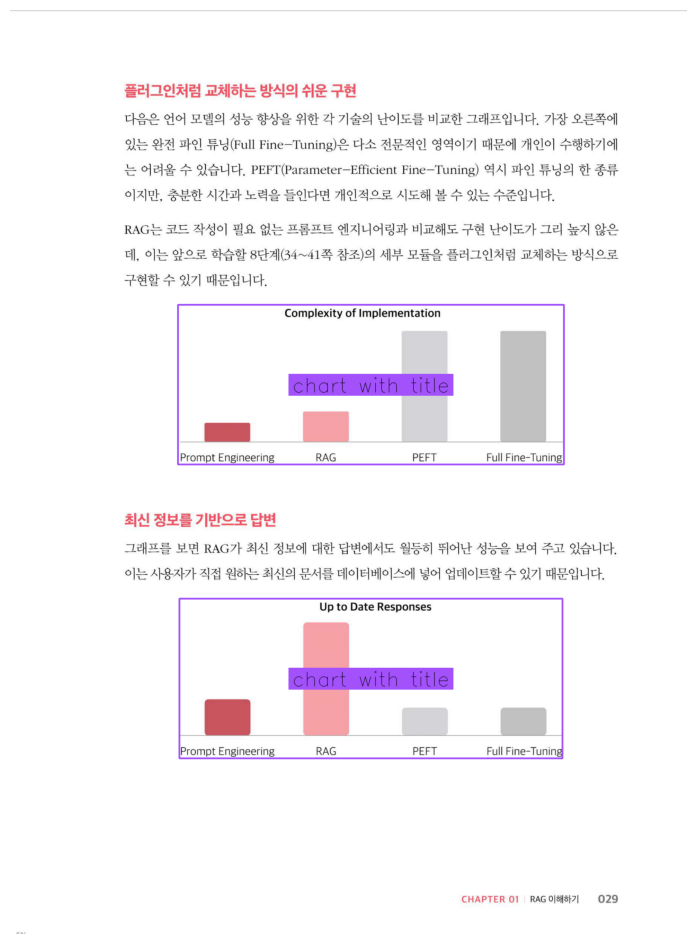

In [22]:
import supervision as sv

resolution_wh = image.size

detections = sv.Detections.from_vlm(
    vlm=sv.VLM.GOOGLE_GEMINI_2_5, result=response.text, resolution_wh=resolution_wh
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    smart_position=True,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_position=sv.Position.CENTER,
)
masks_annotator = sv.MaskAnnotator()

annotated = image
for annotator in (box_annotator, label_annotator, masks_annotator):
    annotated = annotator.annotate(scene=annotated, detections=detections)

sv.plot_image(annotated)

In [32]:
print(response.text)

```json
[
  {"box_2d": [339, 508, 559, 929], "label": "2d bounding box chart with chart title"},
  {"box_2d": [342, 69, 560, 487], "label": "2d bounding box chart with chart title"},
  {"box_2d": [676, 513, 868, 929], "label": "2d bounding box chart with chart title"},
  {"box_2d": [677, 68, 868, 486], "label": "2d bounding box chart with chart title"}
]
```
